# 017 — Human-Mouse Ortholog Bimodality Investigation

Investigates the double-peaked (bimodal) distributions observed in `query_tfidf` and `prob_overlap` for human-mouse ortholog pairs (HP k-mer encoding).

**Key questions:**
1. What drives the low-tfidf peak in orthologs — protein length, k-mer frequency, HP composition, or something else?
2. Are the two peaks statistically distinguishable (e.g. via Gaussian mixture models)?
3. Do the two peaks differ in functional/biological properties (gene family, protein length, sequence identity)?
4. Can we separate the two populations using a combination of features?

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson as _poisson
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

sns.set_theme(style='ticks', context='notebook')
ORTHOLOG_COLOR = '#e63946'
NON_ORTHOLOG_COLOR = '#457b9d'
LOW_PEAK_COLOR = '#f4a261'
HIGH_PEAK_COLOR = '#2a9d8f'

## 1. Load data

In [12]:
KSIZE = 24
DATA_PATH = f'/Users/olga/data/gencode/results-human-mouse-orthologs/ortholog_evaluation.hp.k{KSIZE}.tsv.gz'

SAMPLE_FRAC = 0.05
CHUNK = 500_000

chunks = []
for chunk in pd.read_csv(DATA_PATH, sep='\t', compression='gzip', chunksize=CHUNK):
    mask = rng.random(len(chunk)) < SAMPLE_FRAC
    chunks.append(chunk[mask])

df = pd.concat(chunks, ignore_index=True)
print(f'Loaded {len(df):,} rows')
df.head()

KeyboardInterrupt: 

In [ ]:
# Add derived columns
df['log_query_tfidf'] = np.log10(df['query_tfidf'].clip(lower=1e-10))
df['log_prob_overlap'] = np.log10(df['prob_overlap'].clip(lower=1e-10))
df['log_n_intersecting'] = np.log10(df['n_intersecting_hashes'].clip(lower=0.5))

orthologs = df[df['is_ortholog']]
non_orthologs = df[~df['is_ortholog']]

print(f'Orthologs:     {len(orthologs):,}')
print(f'Non-orthologs: {len(non_orthologs):,}')

Orthologs:     34,325
Non-orthologs: 904,957


## 2. Visualise the bimodality

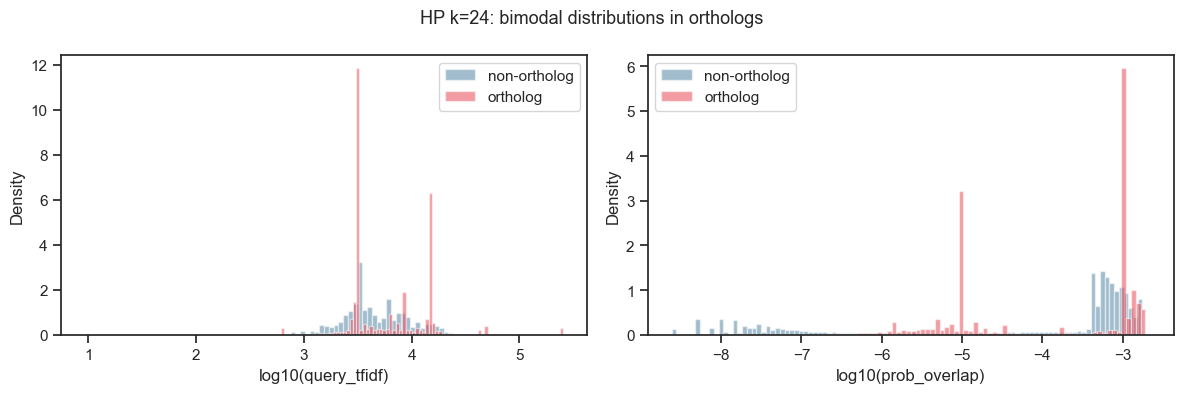

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes,
                          ['log_query_tfidf', 'log_prob_overlap'],
                          ['log10(query_tfidf)', 'log10(prob_overlap)']):
    ax.hist(non_orthologs[col].dropna(), bins=100, alpha=0.5,
            color=NON_ORTHOLOG_COLOR, density=True, label='non-ortholog')
    ax.hist(orthologs[col].dropna(), bins=100, alpha=0.5,
            color=ORTHOLOG_COLOR, density=True, label='ortholog')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()

fig.suptitle(f'HP k={KSIZE}: bimodal distributions in orthologs', fontsize=13)
fig.tight_layout()
plt.show()

## 3. Fit Gaussian Mixture Model to ortholog `query_tfidf`

Use a 2-component GMM to formally identify the two peaks and assign each ortholog to a peak.

In [ ]:
X_orth = orthologs[['log_query_tfidf']].dropna().values

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_orth)

means = gmm.means_.flatten()
order = np.argsort(means)  # low peak first
means_sorted = means[order]
stds_sorted = np.sqrt(gmm.covariances_.flatten())[order]
weights_sorted = gmm.weights_[order]

print('GMM fits (sorted by mean):')
for i, (m, s, w) in enumerate(zip(means_sorted, stds_sorted, weights_sorted)):
    print(f'  Component {i}: mean={m:.3f}, std={s:.3f}, weight={w:.3f}')

labels_orth = gmm.predict(X_orth)
# Remap so label 0 = low peak
if means[0] > means[1]:
    labels_orth = 1 - labels_orth

orthologs = orthologs.copy()
orthologs.loc[orthologs['log_query_tfidf'].notna(), 'gmm_peak'] = labels_orth
orthologs['gmm_peak'] = orthologs['gmm_peak'].map({0: 'low', 1: 'high'})

orthologs['gmm_peak'].value_counts()

GMM fits (sorted by mean):
  Component 0: mean=3.509, std=0.001, weight=0.352
  Component 1: mean=3.915, std=0.416, weight=0.648


gmm_peak
high    22209
low     12116
Name: count, dtype: int64

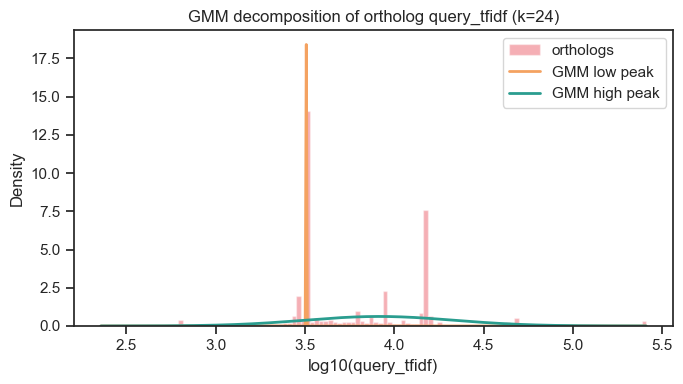

In [ ]:
# Overlay GMM components on histogram
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(X_orth, bins=120, density=True, color=ORTHOLOG_COLOR, alpha=0.4, label='orthologs')

x_grid = np.linspace(X_orth.min(), X_orth.max(), 500)
for i, (m, s, w, c) in enumerate(zip(means_sorted, stds_sorted, weights_sorted,
                                      [LOW_PEAK_COLOR, HIGH_PEAK_COLOR])):
    component = w * (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - m) / s) ** 2)
    ax.plot(x_grid, component, color=c, lw=2, label=f'GMM {["low","high"][i]} peak')

ax.set_xlabel('log10(query_tfidf)')
ax.set_ylabel('Density')
ax.set_title(f'GMM decomposition of ortholog query_tfidf (k={KSIZE})')
ax.legend()
fig.tight_layout()
plt.show()

## 4. Candidate drivers of bimodality

Test each candidate feature: protein length, k-mer frequency, HP composition, and enrichment.

In [ ]:
candidate_cols = [
    'query_len',
    'target_len',
    'n_intersecting_hashes',
    'expected_shared_kmers',
    'mean_matched_kmer_freq',
    'sum_matched_kmer_freq',
    'enrichment',
    'containment',
]

# Keep only columns that exist
candidate_cols = [c for c in candidate_cols if c in orthologs.columns]
print('Available candidate columns:', candidate_cols)

Available candidate columns: ['n_intersecting_hashes', 'expected_shared_kmers', 'mean_matched_kmer_freq', 'sum_matched_kmer_freq', 'enrichment', 'containment']


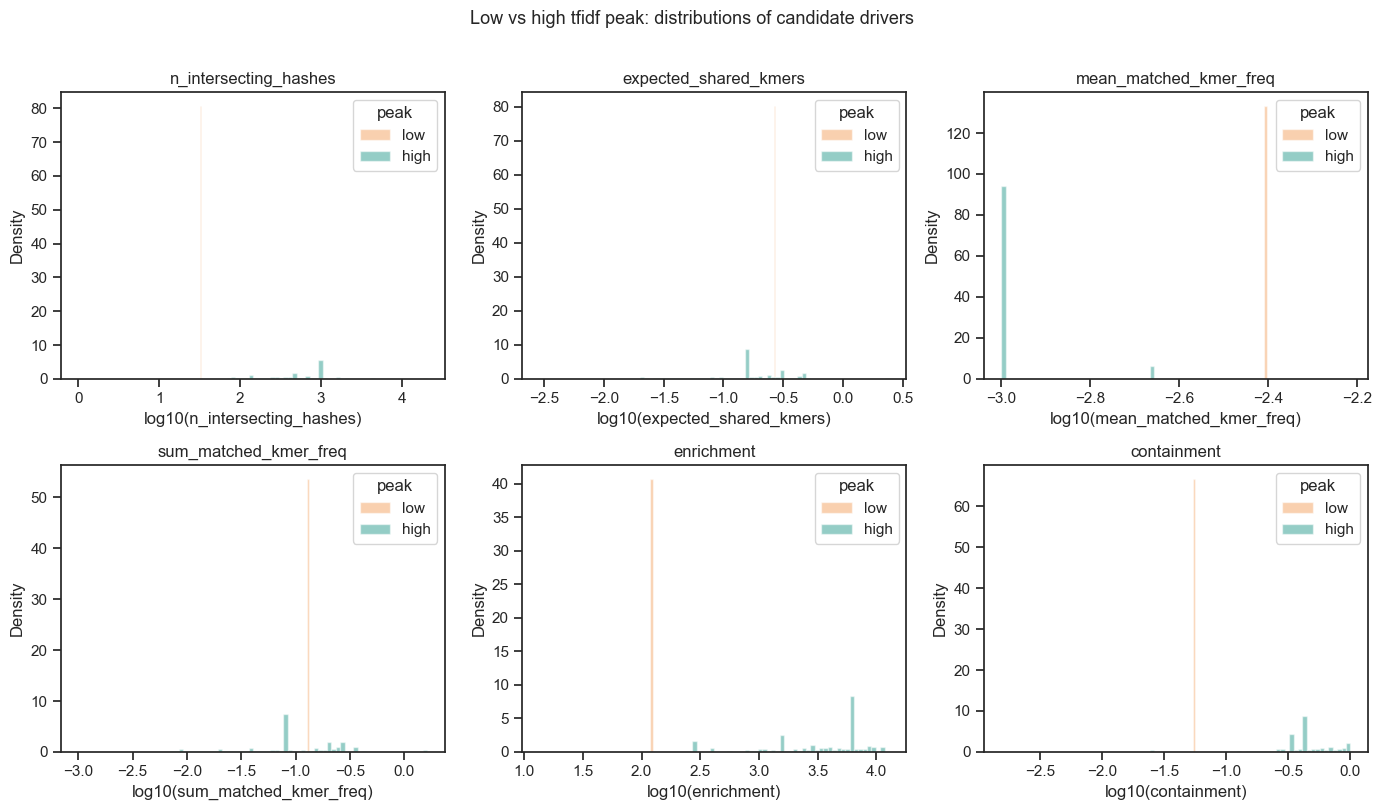

In [ ]:
n_cols = len(candidate_cols)
ncols_plot = 3
nrows_plot = int(np.ceil(n_cols / ncols_plot))

fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(14, 4 * nrows_plot))
axes = axes.flatten()

for ax, col in zip(axes, candidate_cols):
    for peak, color in [('low', LOW_PEAK_COLOR), ('high', HIGH_PEAK_COLOR)]:
        vals = orthologs.loc[orthologs['gmm_peak'] == peak, col].dropna()
        ax.hist(np.log10(vals.clip(lower=1e-3)), bins=80, density=True,
                alpha=0.5, color=color, label=peak)
    ax.set_xlabel(f'log10({col})')
    ax.set_ylabel('Density')
    ax.set_title(col)
    ax.legend(title='peak')

for ax in axes[n_cols:]:
    ax.set_visible(False)

fig.suptitle('Low vs high tfidf peak: distributions of candidate drivers', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 5. Protein-length stratification

Does protein length alone explain the two peaks?

In [ ]:
length_bins = [0, 100, 200, 500, np.inf]
length_labels = ['<100', '100-200', '200-500', '>500']

orthologs['length_bin'] = pd.cut(
    orthologs['query_len'], bins=length_bins, labels=length_labels
)

fig, axes = plt.subplots(1, len(length_labels), figsize=(14, 4), sharey=True)

for ax, lb in zip(axes, length_labels):
    sub = orthologs[orthologs['length_bin'] == lb]['log_query_tfidf'].dropna()
    ax.hist(sub, bins=80, density=True, color=ORTHOLOG_COLOR, alpha=0.7)
    ax.set_title(f'query_len {lb} aa\n(n={len(sub):,})')
    ax.set_xlabel('log10(query_tfidf)')

axes[0].set_ylabel('Density')
fig.suptitle('Ortholog query_tfidf distribution by protein length bin', fontsize=13)
fig.tight_layout()
plt.show()

KeyError: 'query_len'

In [ ]:
# Scatter: query_len vs log_query_tfidf, coloured by GMM peak
sample = orthologs.dropna(subset=['gmm_peak']).sample(min(20_000, len(orthologs)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
for peak, color in [('low', LOW_PEAK_COLOR), ('high', HIGH_PEAK_COLOR)]:
    sub = sample[sample['gmm_peak'] == peak]
    ax.scatter(sub['query_len'], sub['log_query_tfidf'],
               alpha=0.3, s=5, color=color, label=peak, rasterized=True)

ax.set_xlabel('query_len (aa)')
ax.set_ylabel('log10(query_tfidf)')
ax.set_title('Protein length vs query_tfidf (orthologs only)')
ax.legend(title='GMM peak', markerscale=3)
fig.tight_layout()
plt.show()

## 6. HP composition (H-fraction) in matched k-mers

Do the two peaks differ in the hydrophobic fraction of matched regions?

In [ ]:
if 'h_fraction' in orthologs.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    for peak, color in [('low', LOW_PEAK_COLOR), ('high', HIGH_PEAK_COLOR)]:
        vals = orthologs.loc[orthologs['gmm_peak'] == peak, 'h_fraction'].dropna()
        ax.hist(vals, bins=80, density=True, alpha=0.55, color=color, label=peak)
    ax.set_xlabel('H-fraction (hydrophobic residue fraction)')
    ax.set_ylabel('Density')
    ax.set_title('HP composition by GMM peak')
    ax.legend(title='peak')
    fig.tight_layout()
    plt.show()
else:
    print('h_fraction column not present — skipping HP composition plot')

## 7. Statistical enrichment vs expected k-mers

The low peak may represent ortholog pairs where the observed k-mer overlap is not statistically elevated above the Poisson expectation.

In [ ]:
if {'n_intersecting_hashes', 'expected_shared_kmers'}.issubset(orthologs.columns):
    orthologs['poisson_p'] = _poisson.sf(
        orthologs['n_intersecting_hashes'].clip(lower=0) - 1,
        orthologs['expected_shared_kmers'].clip(lower=1e-10)
    )
    orthologs['log_poisson_p'] = np.log10(orthologs['poisson_p'].clip(lower=1e-300))

    fig, ax = plt.subplots(figsize=(7, 4))
    for peak, color in [('low', LOW_PEAK_COLOR), ('high', HIGH_PEAK_COLOR)]:
        vals = orthologs.loc[orthologs['gmm_peak'] == peak, 'log_poisson_p'].dropna()
        ax.hist(vals, bins=100, density=True, alpha=0.55, color=color, label=peak)
    ax.axvline(np.log10(0.05), color='k', ls='--', label='p=0.05')
    ax.set_xlabel('log10(Poisson p-value)')
    ax.set_ylabel('Density')
    ax.set_title('Poisson significance by GMM peak')
    ax.legend(title='peak')
    fig.tight_layout()
    plt.show()
else:
    print('Columns for Poisson test not available')

## 8. Summary table: low vs high peak characterisation

In [ ]:
summary_cols = [c for c in [
    'query_len', 'target_len',
    'n_intersecting_hashes', 'expected_shared_kmers',
    'mean_matched_kmer_freq', 'enrichment', 'containment',
    'query_tfidf', 'prob_overlap',
] if c in orthologs.columns]

summary = (
    orthologs.groupby('gmm_peak')[summary_cols]
    .median()
    .T
    .rename(columns={'low': 'low-peak median', 'high': 'high-peak median'})
)
summary['ratio (high/low)'] = summary['high-peak median'] / summary['low-peak median']
summary.style.format('{:.3g}').background_gradient(subset=['ratio (high/low)'], cmap='RdYlGn')

## 9. BIC model selection: how many peaks?

Formally test whether 1, 2, or 3 Gaussian components best describe the ortholog `query_tfidf` distribution.

In [ ]:
bics = []
aics = []
n_components_range = range(1, 6)

for n in n_components_range:
    g = GaussianMixture(n_components=n, random_state=42)
    g.fit(X_orth)
    bics.append(g.bic(X_orth))
    aics.append(g.aic(X_orth))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_components_range, bics, 'o-', label='BIC')
ax.plot(n_components_range, aics, 's--', label='AIC')
ax.set_xlabel('Number of GMM components')
ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM model selection for ortholog query_tfidf')
ax.legend()
fig.tight_layout()
plt.show()

best_n_bic = n_components_range[np.argmin(bics)]
print(f'Best n_components by BIC: {best_n_bic}')